<a href="https://colab.research.google.com/github/jesusfunez108-png/Estadistica_G1_2026_1/blob/main/5_An%C3%A1lis_de_una_variable_Python_Notebook_y_RMarkdown_con_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Estructura Propuesta del Notebook (Python)

### 1. Introducción y Configuración

**Prompt para el estudiante:**

> "Actúa como un experto en Ciencia de Datos. Explica brevemente qué es el Análisis Exploratorio de Datos (EDA) unidimensional y por qué es fundamental identificar la distribución de una variable antes de realizar inferencia estadística. Resume los conceptos de distribuciones paramétricas y no paramétricas (KDE)."

**Respuesta del experto en Ciencia de Datos:**

El **Análisis Exploratorio de Datos (EDA) unidimensional** se enfoca en comprender las características de una sola variable a la vez. Esto incluye examinar su tendencia central (media, mediana, moda), dispersión (varianza, desviación estándar, rango) y, crucialmente, su **forma de distribución** (simetría, curtosis, unimodalidad/multimodalidad).

Es **fundamental identificar la distribución de una variable antes de realizar inferencia estadística** por varias razones:

1.  **Supuestos de los Test Estadísticos:** Muchos métodos inferenciales (como las pruebas t, ANOVA, regresión lineal) tienen supuestos subyacentes sobre la distribución de los datos (e.g., normalidad). Si estos supuestos no se cumplen, los resultados de la inferencia pueden ser inválidos o engañosos.
2.  **Selección del Modelo:** Conocer la distribución ayuda a elegir el modelo estadístico o algoritmo de aprendizaje automático más adecuado para los datos.
3.  **Comprensión de la Aleatoriedad:** Permite entender cómo se generan los datos y la probabilidad de observar ciertos valores, lo cual es esencial para hacer predicciones y tomar decisiones informadas.
4.  **Detección de Anomalías:** Desviaciones significativas de una distribución esperada pueden indicar la presencia de valores atípicos o errores en los datos.

En cuanto a los tipos de distribuciones:

*   **Distribuciones Paramétricas:** Son aquellas que pueden ser descritas por un conjunto finito de parámetros. Por ejemplo, la distribución Normal se caracteriza por su media (μ) y desviación estándar (σ); la distribución de Poisson por su tasa (λ). Cuando asumimos una distribución paramétrica, estamos asumiendo que los datos provienen de una población que puede ser modelada por estos parámetros específicos.

*   **Distribuciones No Paramétricas (KDE - Estimación de Densidad de Kernel):** A diferencia de las paramétricas, las distribuciones no paramétricas no asumen una forma funcional específica o un conjunto de parámetros predefinidos. La **Estimación de Densidad de Kernel (KDE)** es una técnica no paramétrica utilizada para estimar la función de densidad de probabilidad de una variable aleatoria. Funciona colocando una "función kernel" (comúnmente una función Gaussiana) en cada punto de datos y luego sumando y normalizando estas funciones para obtener una curva de densidad suave que representa la distribución subyacente de los datos. KDE es particularmente útil cuando no se tiene una idea clara de la forma de la distribución de los datos, o cuando la distribución es compleja y no se ajusta bien a un modelo paramétrico conocido. El 'ancho de banda' es un parámetro clave en KDE que controla la suavidad de la curva estimada: un ancho de banda pequeño produce una curva más "picuda" que se ajusta más a los datos individuales, mientras que un ancho de banda grande resulta en una curva más suave y generalizada.

In [ ]:
!pip install fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstal

La librería `fitter` es una herramienta de Python que automatiza el proceso de ajuste de distribuciones de probabilidad a los datos. Puede probar hasta 80 distribuciones de `scipy.stats` y, basándose en criterios como el error cuadrático medio (SSE), el p-valor de Kolmogorov-Smirnov, o los criterios de información de Akaike (AIC) y Bayesiano (BIC), determinar cuál de las distribuciones se ajusta mejor a los datos observados. Esto es muy útil en el Análisis Exploratorio de Datos (EDA) para identificar rápidamente la distribución subyacente de una variable sin tener que probar cada una manualmente.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from fitter import Fitter

# Configuración estética
sns.set_theme(style="whitegrid")

Las líneas de código importan las librerías necesarias para el análisis de datos y la visualización, incluyendo `numpy` para operaciones numéricas, `pandas` para manipulación de datos, `seaborn` y `matplotlib.pyplot` para gráficos, `scipy.stats` para funciones estadísticas, y `fitter` para el ajuste automático de distribuciones. Finalmente, `sns.set_theme(style='whitegrid')` configura un estilo visual para los gráficos de Seaborn, proporcionando un fondo blanco con una cuadrícula.

---

### 2. Demostración de la Probabilidad Frecuentista

**Prompt para el estudiante:**

> "Explica el concepto de Probabilidad Frecuentista o 'A Posteriori'. Define la fórmula del límite cuando $N$ tiende a infinito y explica cómo una simulación de Monte Carlo puede demostrar que la frecuencia relativa converge a la probabilidad teórica."

El concepto de **Probabilidad Frecuentista** o 'A Posteriori' se basa en la idea de que la probabilidad de un evento se puede determinar observando su frecuencia relativa en una serie larga de ensayos o experimentos repetidos. En otras palabras, si un experimento se repite un gran número de veces bajo las mismas condiciones, la frecuencia con la que ocurre un evento particular tenderá a estabilizarse y acercarse a su verdadera probabilidad. Es 'A Posteriori' porque se estima después de haber observado los resultados de los experimentos.

La fórmula del límite cuando N tiende a infinito se expresa como:

$$ P(A) = \lim_{N \to \infty} \frac{\text{Número de veces que ocurre A}}{N} $$

Donde:
*   $P(A)$ es la probabilidad del evento A.
*   $N$ es el número total de ensayos o repeticiones del experimento.
*   $\text{Número de veces que ocurre A}$ es la cantidad de veces que el evento A sucede en esos $N$ ensayos.


Una **simulación de Monte Carlo** es una técnica computacional que utiliza la generación de números aleatorios para modelar y analizar sistemas complejos o para estimar cantidades que son difíciles de calcular analíticamente. Puede demostrar que la frecuencia relativa converge a la probabilidad teórica de la siguiente manera:

1.  **Definición del Evento:** Se define un experimento con un evento de interés cuya probabilidad teórica se conoce (o se puede calcular).
2.  **Repetición del Experimento:** Se simula el experimento un gran número de veces ($N$) utilizando un generador de números aleatorios. En cada simulación, se registra si el evento de interés ocurre o no.
3.  **Cálculo de la Frecuencia Relativa:** Después de cada conjunto de simulaciones (o iterativamente a medida que $N$ aumenta), se calcula la frecuencia relativa del evento dividiendo el número de veces que ocurrió el evento entre el número total de simulaciones realizadas.
4.  **Observación de la Convergencia:** A medida que el número de simulaciones ($N$) aumenta, la Ley de los Grandes Números establece que la frecuencia relativa observada se acercará cada vez más a la probabilidad teórica del evento. Una simulación de Monte Carlo permite visualizar esta convergencia, mostrando cómo las fluctuaciones iniciales en la frecuencia relativa se suavizan y se asientan en el valor de la probabilidad teórica a medida que se acumulan más ensayos.

In [ ]:
1/6

0.16666666666666666

In [ ]:
# Simulación de control de aire acondicionado (6 unidades)
unidades = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
n_simulaciones = [10, 100, 1000, 10000]

print("Convergencia de la Frecuencia Relativa (Probabilidad Teórica = 0.1666)\n")
for n in n_simulaciones:
    muestra = pd.Series(np.random.choice(unidades, size=n))
    frec_relativa = muestra.value_counts(normalize=True).sort_index()
    print(f"Resultados con N={n}:")
    print(frec_relativa.to_string(), "\n")

Convergencia de la Frecuencia Relativa (Probabilidad Teórica = 0.1666)

Resultados con N=10:
A1    0.1
A2    0.3
A3    0.3
A4    0.1
A5    0.1
A6    0.1 

Resultados con N=100:
A1    0.14
A2    0.14
A3    0.20
A4    0.10
A5    0.18
A6    0.24 

Resultados con N=1000:
A1    0.152
A2    0.181
A3    0.162
A4    0.156
A5    0.173
A6    0.176 

Resultados con N=10000:
A1    0.1666
A2    0.1699
A3    0.1677
A4    0.1645
A5    0.1686
A6    0.1627 



---

### 3. Tabla de Distribución de Frecuencias (TDF) en Python

**Prompt para el estudiante:**

> "Investiga la Regla de Sturges para calcular el número de intervalos (bins) en un histograma. ¿Cuáles son las diferencias entre frecuencia absoluta, relativa y acumulada? Pide a Gemini que explique la importancia de la 'Marca de Clase' en el análisis de datos agrupados."

La **Regla de Sturges** es una de las fórmulas más utilizadas para determinar el número de intervalos (o 'bins') óptimos al construir un histograma. La fórmula es:

$$ k = 1 + 3.322 \log_{10}(n) $$

Donde:
*   $k$ es el número de intervalos.
*   $n$ es el número total de observaciones en el conjunto de datos.

Esta regla busca encontrar un equilibrio entre tener suficientes intervalos para mostrar la forma de la distribución y no tener demasiados que hagan el histograma demasiado "ruidoso" o con celdas vacías.

---

Las **frecuencias** en el análisis de datos se definen de la siguiente manera:

*   **Frecuencia Absoluta (f):** Es el número de veces que un valor específico o una categoría aparece en un conjunto de datos. Para datos agrupados, es el número de observaciones que caen dentro de un intervalo de clase determinado.
*   **Frecuencia Relativa (h):** Es la proporción de veces que un valor o categoría aparece en el conjunto de datos, calculada dividiendo la frecuencia absoluta por el número total de observaciones. Se expresa comúnmente como un decimal o un porcentaje. Indica la importancia de una categoría o valor en relación con el total.
*   **Frecuencia Acumulada (F o H):**
    *   **Frecuencia Absoluta Acumulada (F):** Es la suma de las frecuencias absolutas de todos los valores o categorías hasta un punto dado. Para datos agrupados, es la suma de las frecuencias absolutas de los intervalos de clase anteriores y el actual.
    *   **Frecuencia Relativa Acumulada (H):** Es la suma de las frecuencias relativas hasta un punto dado. Indica la proporción acumulada de observaciones hasta un cierto valor o intervalo. La última frecuencia relativa acumulada siempre será 1 (o 100%).

---

La **'Marca de Clase' (mc)** en el análisis de datos agrupados es el punto medio de cada intervalo de clase. Se calcula como la suma del límite inferior y el límite superior de un intervalo dividida por dos:

$$ mc = \frac{\text{Límite Inferior} + \text{Límite Superior}}{2} $$

**Importancia de la 'Marca de Clase':**

En el análisis de datos agrupados, la información individual de cada dato se pierde al agruparlos en intervalos. La marca de clase es crucial porque **representa el valor típico o el punto central de todos los datos que caen dentro de ese intervalo**. Su importancia radica en que:

*   **Cálculo de Estadísticos:** Permite estimar estadísticos importantes como la media, la mediana o la varianza de los datos agrupados, ya que, al no tener los valores individuales, se asume que la marca de clase es el valor representativo de todas las observaciones dentro de ese intervalo.
*   **Visualización:** Se utiliza para graficar los datos agrupados en un histograma o un polígono de frecuencias, donde la marca de clase se ubica en el eje horizontal para representar el centro de cada barra o punto.
*   **Análisis Comparativo:** Facilita la comparación entre diferentes conjuntos de datos agrupados al proporcionar un punto de referencia para cada intervalo.

In [ ]:
import pandas as pd
import numpy as np

def generar_tdf(datos, nombre_var="Variable"):
    n = len(datos)
    k = int(1 + 3.322 * np.log10(n)) # Regla de Sturges
    rango = datos.max() - datos.min()
    ancho = np.ceil(rango / k)

    bins = [datos.min() + i*ancho for i in range(k+1)]

    tdf = pd.DataFrame()
    counts, edges = np.histogram(datos, bins=bins)

    tdf['Linf'] = edges[:-1]
    tdf['Lsup'] = edges[1:]
    tdf['mc'] = (tdf['Linf'] + tdf['Lsup']) / 2
    tdf['f'] = counts
    tdf['h'] = counts / n
    tdf['F'] = tdf['f'].cumsum()
    tdf['H'] = tdf['h'].cumsum()

    return tdf

# Ejemplo con datos de Boston (California Housing en Colab)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# print(df_housing)

print("Tabla de Frecuencias para 'MedInc' (Ingreso Medio):")
display(generar_tdf(df_housing['MedInc']))

Tabla de Frecuencias para 'MedInc' (Ingreso Medio):


,Linf,Lsup,mc,f,h,F,H
0,0.4999,1.4999,0.9999,815,0.039486,815,0.039486
1,1.4999,2.4999,1.9999,3962,0.191957,4777,0.231444
2,2.4999,3.4999,2.9999,5316,0.257558,10093,0.489002
3,3.4999,4.4999,3.9999,4522,0.219089,14615,0.708091
4,4.4999,5.4999,4.9999,2807,0.135998,17422,0.844089
5,5.4999,6.4999,5.9999,1564,0.075775,18986,0.919864
6,6.4999,7.4999,6.9999,704,0.034109,19690,0.953973
7,7.4999,8.4999,7.9999,443,0.021463,20133,0.975436
8,8.4999,9.4999,8.9999,155,0.007510,20288,0.982946
9,9.4999,10.4999,9.9999,134,0.006492,20422,0.989438


---

### 4. Visualización: Histograma y Densidad (KDE)

**Prompt para el estudiante:**

> "¿Qué es la Estimación de Densidad de Kernel (KDE)? Explica cómo se construye la curva sumando gaussianas individuales y qué función cumple el parámetro 'bandwidth' (ancho de banda) en el suavizado de la curva."

La **Estimación de Densidad de Kernel (KDE)** es una técnica no paramétrica utilizada para estimar la función de densidad de probabilidad de una variable aleatoria. A diferencia de un histograma, que usa bins discretos, KDE produce una curva suave que representa la distribución subyacente de los datos.

Se construye **sumando gaussianas individuales** (o funciones kernel) centradas en cada punto de datos. Imagina colocar una pequeña "colina" o "campana" (una función gaussiana) sobre cada observación en tu conjunto de datos. Luego, estas colinas se suman para formar una única curva suave que representa la densidad de probabilidad general de los datos.

El parámetro clave es el **'bandwidth' (ancho de banda)**, que controla la "anchura" de cada gaussiana individual y, por lo tanto, la suavidad de la curva estimada final:

*   Un **ancho de banda pequeño** produce una curva más "picuda" y sensible a cada punto de dato, lo que puede resultar en una estimación "ruidosa" que captura demasiados detalles o ruido en los datos.
*   Un **ancho de banda grande** produce una curva más suave y generalizada, lo que puede ocultar detalles importantes de la distribución subyacente al suavizarla en exceso. La elección adecuada del ancho de banda es crucial para obtener una estimación precisa de la distribución.

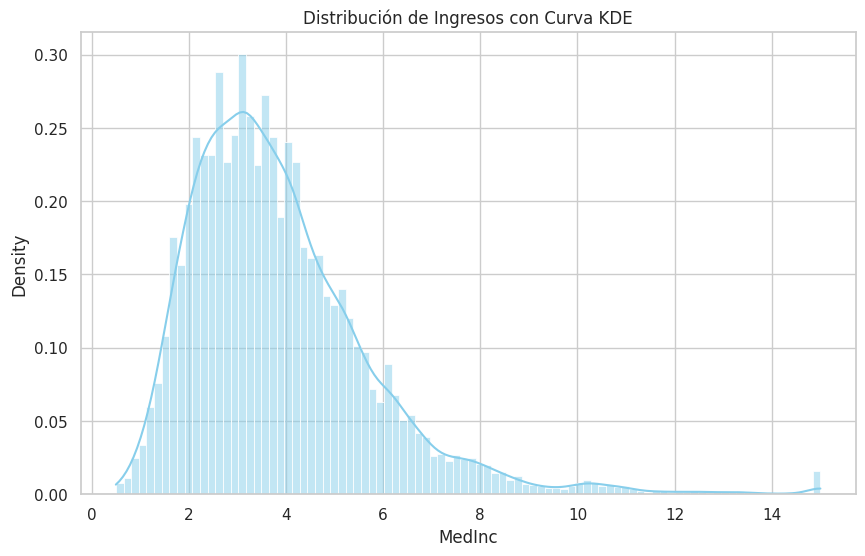

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.histplot(df_housing['MedInc'], kde=True, stat="density", color="skyblue")
plt.title("Distribución de Ingresos con Curva KDE")
plt.show()

Estas líneas de código utilizan las librerías `seaborn` y `matplotlib.pyplot` para visualizar la distribución de la variable 'MedInc' del DataFrame `df_housing`:

*   `import seaborn as sns` y `import matplotlib.pyplot as plt`: Importan las librerías necesarias para la visualización de datos.
*   `plt.figure(figsize=(10,6))`: Crea una nueva figura para el gráfico con un tamaño específico (10 pulgadas de ancho por 6 de alto).
*   `sns.histplot(df_housing['MedInc'], kde=True, stat="density", color="skyblue")`: Genera un histograma de la columna 'MedInc'.
    *   `kde=True`: Superpone una Estimación de Densidad de Kernel (KDE) sobre el histograma, mostrando una curva suave que representa la distribución de los datos.
    *   `stat="density"`: Normaliza las barras del histograma para que su área total sea 1, lo que permite compararlas con la curva KDE (una función de densidad de probabilidad).
    *   `color="skyblue"`: Establece el color de las barras del histograma en azul cielo.
*   `plt.title("Distribución de Ingresos con Curva KDE")`: Añade un título al gráfico.
*   `plt.show()`: Muestra el gráfico generado.

---

### 5. Ajuste de Distribuciones Teóricas

**Prompt para el estudiante:**

> "Explica el proceso de 'ajuste de bondad' (Goodness of Fit). ¿Qué busca el test de Kolmogorov-Smirnov y cómo se interpreta el p-valor para decidir si un conjunto de datos sigue una distribución Normal o Gamma?"

El **'ajuste de bondad' (Goodness of Fit)** es un proceso estadístico que evalúa qué tan bien un modelo (en este caso, una distribución de probabilidad teórica) se ajusta a un conjunto de datos observados. En esencia, busca determinar si los datos empíricos podrían haber sido generados por la distribución teórica propuesta. No se trata de probar que los datos *son* de una distribución específica, sino de ver si *no hay evidencia suficiente* para rechazar esa hipótesis.

El **Test de Kolmogorov-Smirnov (KS)** es una prueba no paramétrica utilizada para determinar si una muestra de datos proviene de una distribución de probabilidad específica (prueba de una muestra) o si dos muestras de datos provienen de la misma distribución (prueba de dos muestras). En el contexto de 'ajuste de bondad', se usa para comparar la función de distribución acumulada (CDF) empírica de los datos con la CDF teórica de la distribución que se está probando.

Lo que busca el test KS es la **máxima diferencia absoluta** entre la CDF empírica y la CDF teórica. Si esta diferencia es grande, sugiere que los datos no se ajustan bien a la distribución propuesta.

**Interpretación del p-valor para decidir si un conjunto de datos sigue una distribución Normal o Gamma:**

El **p-valor** es la probabilidad de observar un resultado tan extremo como (o más extremo que) el obtenido, asumiendo que la hipótesis nula (H0) es verdadera. En el test de Kolmogorov-Smirnov, la hipótesis nula es que los datos provienen de la distribución especificada (por ejemplo, Normal o Gamma).

*   **Si el p-valor > Nivel de Significación (usualmente 0.05):** Esto significa que no hay suficiente evidencia estadística para rechazar la hipótesis nula. Por lo tanto, se concluye que **los datos podrían seguir la distribución teórica propuesta** (Normal o Gamma en este caso). No significa que los datos *son* de esa distribución, sino que el test no encontró una diferencia significativa para decir que no lo son.
*   **Si el p-valor <= Nivel de Significación (usualmente 0.05):** Esto significa que hay suficiente evidencia estadística para rechazar la hipótesis nula. Por lo tanto, se concluye que **los datos probablemente no siguen la distribución teórica propuesta** (Normal o Gamma). La diferencia entre la distribución de los datos y la distribución teórica es demasiado grande para ser atribuida únicamente al azar.

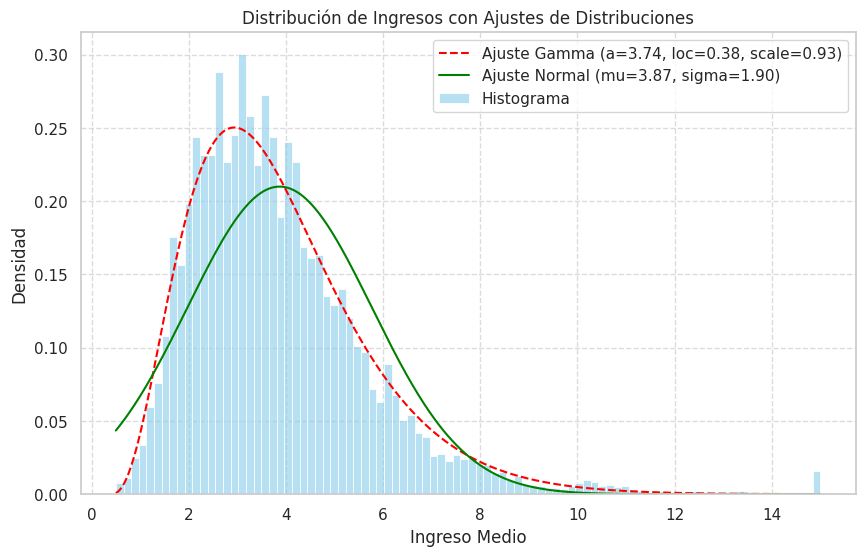

P-valor (Normal): 4.518e-144
Resultado: No es Normal
P-valor (Gamma): 1.678e-09
Resultado: No es Gamma


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Ajuste visual con Seaborn
data = df_housing['MedInc']
plt.figure(figsize=(10,6))

# Plot histogram
sns.histplot(data, stat="density", color="skyblue", label="Histograma", alpha=0.6, bins='auto')

# Fit and plot Gamma distribution
gamma_params = stats.gamma.fit(data) # returns (a, loc, scale)
x_gamma = np.linspace(data.min(), data.max(), 500)
pdf_gamma = stats.gamma.pdf(x_gamma, *gamma_params)
plt.plot(x_gamma, pdf_gamma, color="red", linestyle='--', label=f"Ajuste Gamma (a={gamma_params[0]:.2f}, loc={gamma_params[1]:.2f}, scale={gamma_params[2]:.2f})")

# Fit and plot Normal distribution
norm_params = stats.norm.fit(data) # returns (loc, scale)
x_norm = np.linspace(data.min(), data.max(), 500)
pdf_norm = stats.norm.pdf(x_norm, *norm_params)
plt.plot(x_norm, pdf_norm, color="green", linestyle='-', label=f"Ajuste Normal (mu={norm_params[0]:.2f}, sigma={norm_params[1]:.2f})")

plt.title("Distribución de Ingresos con Ajustes de Distribuciones")
plt.xlabel("Ingreso Medio")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Test de Kolmogorov-Smirnov para Normal
d_norm, p_valor_norm = stats.kstest(data, "norm", args=norm_params)
print(f"P-valor (Normal): {p_valor_norm:.3e}")
print("Resultado: Es Normal" if p_valor_norm > 0.05 else "Resultado: No es Normal")

# Test de Kolmogorov-Smirnov para Gamma
d_gamma, p_valor_gamma = stats.kstest(data, "gamma", args=gamma_params)
print(f"P-valor (Gamma): {p_valor_gamma:.3e}")
print("Resultado: Es Gamma" if p_valor_gamma > 0.05 else "Resultado: No es Gamma")

---

### 6. Selección Automática con Fitter

**Prompt para el estudiante:**

> "Documenta el uso de la librería 'Fitter'. ¿Cómo ayuda a automatizar la búsqueda de la mejor distribución entre las 80 disponibles en Scipy? Explica qué es el error cuadrático medio en este contexto."

La librería **`Fitter`** es una herramienta de Python que simplifica drásticamente el proceso de **ajuste de distribuciones de probabilidad a un conjunto de datos**. Tradicionalmente, identificar la distribución teórica que mejor describe los datos es una tarea manual que implica probar diferentes distribuciones, visualizar sus ajustes y realizar pruebas estadísticas de bondad de ajuste.

**¿Cómo ayuda a automatizar la búsqueda de la mejor distribución entre las 80 disponibles en Scipy?**

`Fitter` automatiza este proceso de la siguiente manera:

1.  **Iteración Automática:** Permite al usuario especificar una lista de distribuciones candidatas (o probar todas las disponibles en `scipy.stats`, que son más de 80). `Fitter` itera automáticamente sobre cada una de estas distribuciones.
2.  **Ajuste y Parámetros:** Para cada distribución, `Fitter` utiliza los datos para estimar sus parámetros óptimos (por ejemplo, media y desviación estándar para una Normal, o parámetros `a`, `loc`, `scale` para una Gamma).
3.  **Cálculo de Criterios de Ajuste:** Una vez que se ajustan los parámetros, `Fitter` calcula una métrica de


--- Mejor Distribución Encontrada ---
Distribución: lognorm
Parámetros:
  - s: 0.4203
  - loc: -0.3674
  - scale: 3.8772


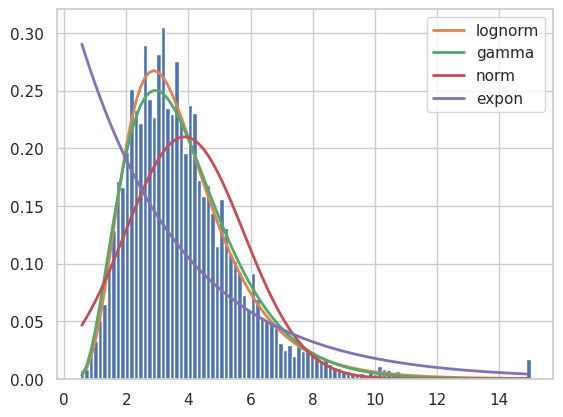

In [ ]:
# Este paso puede tardar unos segundos
f = Fitter(data, distributions=['gamma', 'lognorm', 'norm', 'expon'])
f.fit()
f.summary()

# Obtener la mejor distribución y sus parámetros
best_dist_info = f.get_best(method='sumsquare_error')

# Extraer el nombre de la distribución y sus parámetros
best_dist_name = list(best_dist_info.keys())[0]
best_dist_params = best_dist_info[best_dist_name]

print("\n--- Mejor Distribución Encontrada ---")
print(f"Distribución: {best_dist_name}")
print("Parámetros:")
for param, value in best_dist_params.items():
    # Asegurarse de que el valor es un número antes de formatear
    if isinstance(value, (int, float, np.number)):
        print(f"  - {param}: {value:.4f}")
    else:
        print(f"  - {param}: {value}")

La librería `fitter` ha determinado que la distribución que mejor se ajusta a los datos es la **Log-Normal** (`lognorm`).

La función de densidad de probabilidad (PDF) para la distribución log-normal está definida por los parámetros de forma (s), ubicación (loc) y escala (scale). La ecuación general es:

$$ f(x) = \frac{1}{(x - \text{loc}) \cdot s \cdot \sqrt{2\pi}} \exp\left(-\frac{(\ln(x - \text{loc}) - \ln(\text{scale}))^2}{2s^2}\right) \quad \text{para } x > \text{loc} $$

Sustituyendo los parámetros obtenidos de nuestros datos:
*   `s` = 0.4203
*   `loc` = -0.3674
*   `scale` = 3.8772

La ecuación específica para la distribución que mejor ajusta nuestros datos es:

$$ f(x) = \frac{1}{(x - (-0.3674)) \cdot 0.4203 \cdot \sqrt{2\pi}} \exp\left(-\frac{(\ln(x - (-0.3674)) - \ln(3.8772))^2}{2 \cdot (0.4203)^2}\right) $$

Que se simplifica a:

$$ f(x) = \frac{1}{(x + 0.3674) \cdot 0.4203 \cdot \sqrt{2\pi}} \exp\left(-\frac{(\ln(x + 0.3674) - \ln(3.8772))^2}{2 \cdot (0.4203)^2}\right) \quad \text{para } x > -0.3674 $$

# QUEDAMOS AQUI PARA CONTINUAR CON CÓDIGO DE R QUE HAGA LOS AJUSTES DE DATOS A DISTRIBUCIONES DE PROBABILIDAD

---

## Guía para el Estudiante: De Python a RMarkdown

Para finalizar el ejercicio y cumplir con los requisitos de la asignatura, sigue estos pasos en tu entorno local o Posit Cloud:

### 1. Crear el archivo RMarkdown

Abre RStudio y crea un nuevo archivo `.Rmd`. Asegúrate de tener instalada la librería `reticulate` para ejecutar el código de Python que desarrollaste.

### 2. Estructura del Documento

```markdown
---
title: "Análisis de Distribuciones: Python + R"
author: "Tu Nombre"
output: html_document
---

# Introducción
En este documento se integra el análisis realizado en Python...

```{r setup}
library(reticulate)
# Esto permite que R use el entorno de Python

```

# Ejecución de Código Python

```{python}
# Aquí pegas el código de ajuste de distribuciones desarrollado arriba
import numpy as np
# ... (tu código)

```

# Publicación

1. **GitHub:** Sube tu archivo `.Rmd` y el `.html` resultante a un repositorio.
2. **RPubs:** En RStudio, haz clic en el botón **Publish** (esquina superior derecha de la consola) y selecciona RPubs.

```

### 3. Entregables
* **URL de GitHub:** Donde se aloja el código fuente.
* **URL de RPubs:** Donde se visualiza el reporte profesional renderizado.

```